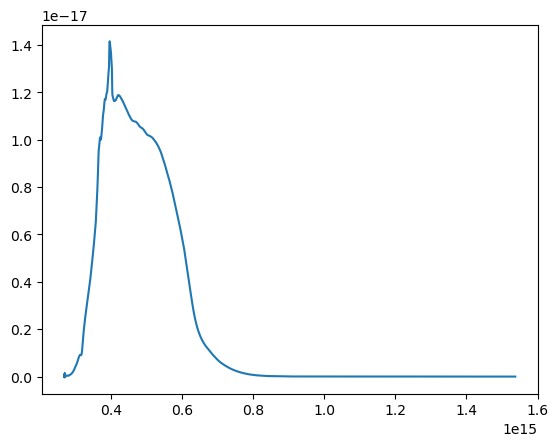

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from numpy.fft import ifft, fftshift, fftfreq

# Load CSV data
df = pd.read_csv("mean_bk7_spectrum.csv")  # Replace with your filename
df.rename(columns={"Wavelength(nm)": "wavelength_nm", "Intensity": "intensity"}, inplace=True)

# Convert wavelength (nm) to frequency (Hz)
df["wavelength_m"] = df["wavelength_nm"] * 1e-9
c = 3.0e8  # Speed of light (m/s)
df["frequency_Hz"] = c / df["wavelength_m"]

# Apply Jacobian correction: I(nu) = I(lambda) * c / nu^2
df["intensity_corrected"] = df["intensity"] * (c / df["frequency_Hz"]**2)

plt.plot(df["frequency_Hz"], df["intensity_corrected"], label="Corrected Intensity")




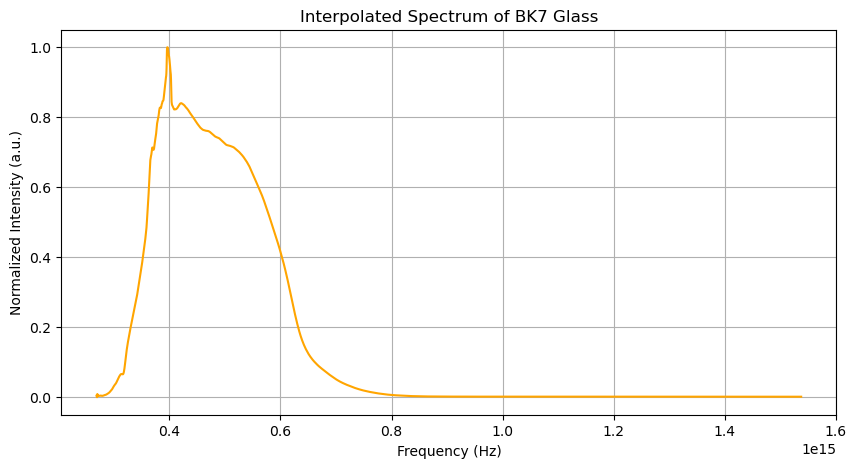

In [3]:
# Sort by frequency (ascending)
df_sorted = df.sort_values(by="frequency_Hz").reset_index(drop=True)

# Interpolate to equidistant frequency grid
original_freqs = df_sorted["frequency_Hz"].values
original_intensities = df_sorted["intensity_corrected"].values
uniform_freqs = np.linspace(original_freqs.min(), original_freqs.max(), len(original_freqs))

# Use cubic interpolation
interpolator = interp1d(original_freqs, original_intensities, kind='cubic')
interpolated_intensities = interpolator(uniform_freqs)

# Normalize intensity to [0, 1]
min_intensity = interpolated_intensities.min()
max_intensity = interpolated_intensities.max()
intensity_scaled = (interpolated_intensities - min_intensity) / (max_intensity - min_intensity)


# Plot the interpolated spectrum
plt.figure(figsize=(10, 5))
plt.plot(uniform_freqs, intensity_scaled, label="Interpolated Spectrum", color='orange')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Intensity (a.u.)")
plt.title("Interpolated Spectrum of BK7 Glass")
plt.grid(True)


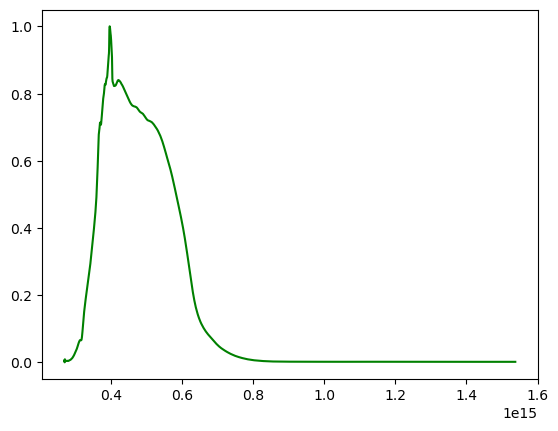

In [4]:
def pad_frequency_data(x, y, padding_factor=1):
    """
    Pads the input frequency (x) and intensity (y) arrays with zeros.
    
    Parameters:
        x (np.ndarray): Original frequency array (must be uniformly spaced).
        y (np.ndarray): Original intensity array (same length as x).
        padding_factor (float): Fractional multiple of the original array length to pad.
                                For example, 1 means add the same number of zero points.
    
    Returns:
        x_padded (np.ndarray): Padded frequency array.
        y_padded (np.ndarray): Padded intensity array (with zeros).
    """
    if len(x) != len(y):
        raise ValueError("x and y must be the same length.")
    
    n_padding = int(len(x) * padding_factor)
    freq_step = x[1] - x[0]  # Assuming uniform spacing
    
    # Generate padded x and y
    x_pad = np.linspace(x[-1] + freq_step, x[-1] + freq_step * n_padding, n_padding)
    y_pad = np.zeros(n_padding)
    
    # Concatenate
    x_padded = np.concatenate((x, x_pad))
    y_padded = np.concatenate((y, y_pad))
    
    return x_padded, y_padded

frequency_padded, intensity_padded = pad_frequency_data(uniform_freqs, intensity_scaled, padding_factor=0)

plt.plot(frequency_padded, intensity_padded, label="Padded Spectrum", color='green') 

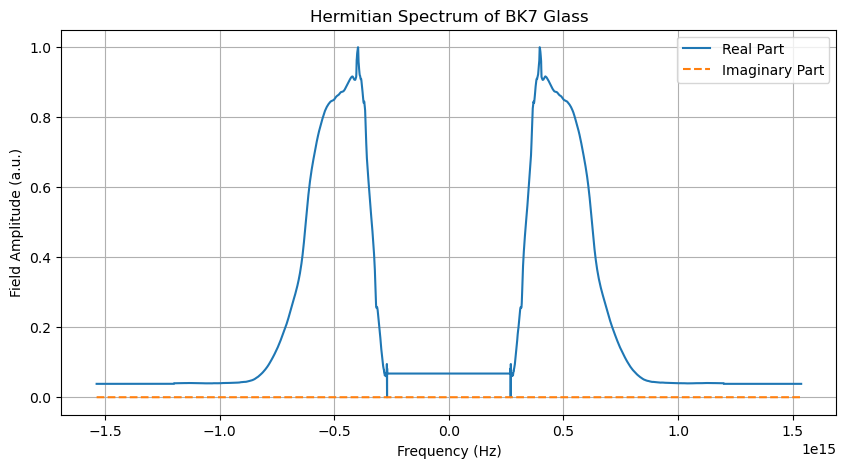

In [5]:
from attr import field


def mirror_frequency_axis(x, y):
    """
    Create a mirrored frequency axis and spectrum for FFT.

    Parameters:
        x (np.ndarray): Frequency array (positive only, uniformly spaced).
        y (np.ndarray): Intensity or field array.

    Returns:
        x_mirrored (np.ndarray): Symmetric frequency array (-f_max to +f_max).
        y_mirrored (np.ndarray): Hermitian-symmetric spectrum (conj mirror of y).
    """
    if len(x) != len(y):
        raise ValueError("x and y must be the same length.")
    if not np.allclose(np.diff(x), np.diff(x)[0]):
        raise ValueError("Frequency axis must be uniformly spaced.")

    # Skip the DC term to avoid double-counting zero
    x_neg = -x[::-1][1:]
    y_neg = np.conj(y[::-1][1:])  # Hermitian symmetry

    x_mirrored = np.concatenate((x_neg, x))
    y_mirrored = np.concatenate((y_neg, y))

    return x_mirrored, y_mirrored

field_magnitude = np.sqrt(intensity_padded).astype(np.complex128)  # Construct real field spectrum (zero phase)

frequency_mirrored, field_hermitian = mirror_frequency_axis(frequency_padded, field_magnitude)


# plot the real and imaginary parts of the Hermitian spectrum
plt.figure(figsize=(10, 5))
plt.plot(frequency_mirrored, field_hermitian.real, label="Real Part")
plt.plot(frequency_mirrored, field_hermitian.imag, label="Imaginary Part", linestyle='--')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Field Amplitude (a.u.)")
plt.title("Hermitian Spectrum of BK7 Glass")
plt.grid(True)
plt.legend()




In [8]:
np.fft.ifftshift(frequency_mirrored)

array([ 2.69065777e+14,  2.69413563e+14,  2.69761350e+14, ...,
       -2.69761350e+14, -2.69413563e+14, -2.69065777e+14])

In [7]:

# # Compute IFFT
# delta_f = uniform_freqs[1] - uniform_freqs[0]
# time_domain_field = ifft(field_hermitian)

# time_domain_field_shifted = fftshift(time_domain_field)

# # Time axis
# time_axis = fftshift(fftfreq(len(field_hermitian), d=delta_f))
# time_axis_fs = time_axis * 1e15  # convert to femtoseconds

# # Plot zoomed field (±50 fs)
# mask = (time_axis_fs >= -10) & (time_axis_fs <= 10)

# plt.figure(figsize=(10, 5))
# plt.plot(time_axis_fs[mask], time_domain_field_shifted.real[mask], label="Real Part")
# plt.plot(time_axis_fs[mask], time_domain_field_shifted.imag[mask], label="Imaginary Part", linestyle='--')
# plt.xlabel("Time (fs)")
# plt.ylabel("Field Amplitude (a.u.)")
# plt.title("Zoomed Time-Domain Field")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()